# 01 – Data Understanding

**Project:** Loan Default Prediction (LendingClub accepted loans)

**Purpose of this notebook:** understand the structure, quality and meaning of the raw data; decide which columns are legitimate model inputs; and record the cleaning actions to be carried out in the next stage.

**Prediction point:** application time, i.e. before the lender evaluates the application. Only information available at that point may be used as a model input. Anything generated after the application is evaluated or the loan is issued is treated as potential data leakage.

## 1. Setup

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)

## 2. Data Loading

In [4]:
DATA_PATH = Path("..") / "data" / "interim" / "accepted_2007_to_201804.parquet"
df = pd.read_parquet(DATA_PATH)

## 3. Initial Inspection

In [5]:
df.shape  # (2260701, 151)

(2260701, 151)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: Int64(1), datetime64[ns](11), float64(112), object(27)
memory usage: 2.5+ GB


In [7]:
print(df.dtypes.to_string())

id                                                    object
member_id                                              Int64
loan_amnt                                            float64
funded_amnt                                          float64
funded_amnt_inv                                      float64
term                                                  object
int_rate                                             float64
installment                                          float64
grade                                                 object
sub_grade                                             object
emp_title                                             object
emp_length                                            object
home_ownership                                        object
annual_inc                                           float64
verification_status                                   object
issue_d                                       datetime64[ns]
loan_status             

### Preview of the data

In [8]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,<NA>,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,None,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,2003-08-01,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,2019-01-01,122.67,NaT,2019-03-01,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,None,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,NaT,NaT,NaT,NaN,NaN,None,NaN,NaN,NaN,Cash,N,NaT,None,NaT,NaN,NaN,NaN
1,68355089,<NA>,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,None,small_business,Business,577xx,SD,16.06,1.0,1999-12-01,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,2016-06-01,926.35,NaT,2019-03-01,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,None,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24

In [9]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,<NA>,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.0,Verified,2016-10-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,None,debt_consolidation,None,907xx,CA,12.75,7.0,1995-02-01,705.0,709.0,1.0,9.0,NaN,5.0,0.0,8633.0,64.9,37.0,f,23252.59,23252.59,24903.93,24903.93,16747.41,8156.52,0.00,0.0,0.0,2019-03-01,859.56,2019-04-01,2019-03-01,724.0,720.0,0.0,10.0,1.0,Individual,NaN,NaN,None,0.0,0.0,28398.0,0.0,2.0,0.0,1.0,15.0,19765.0,46.0,0.0,0.0,5141.0,51.0,13300.0,3.0,0.0,2.0,2.0,5680.0,4070.0,66.9,0.0,0.0,154.0,258.0,33.0,15.0,3.0,41.0,9.0,1.0,9.0,6.0,2.0,3.0,2.0,15.0,9.0,3.0,23.0,3.0,5.0,0.0,0.0,7.0,0.0,75.7,50.0,0.0,0.0,55970.0,28398.0,12300.0,42670.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,NaT,NaT,NaT,NaN,NaN,None,NaN,NaN,NaN,Cash,N,NaT,None,NaT,NaN,NaN,NaN
2260697,88224441,<NA>,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.0,Not Verified,2016-10-01,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,None,debt_consolidation,Debt consolidation,334xx,FL,18.30,0.0,1999-07-01,660.0,664.0,0.0,67.0,72.0,10.0,1.0,17641.0,68.1,31.0,f,0.00,0.00,6755.40,6755.40,3521.91,3233.49,0.00,0.0,0.0,2017-10-01,564.56,NaT,2019-03-01,594.0,590.0,0.0,67.0,1.0,Individual,NaN,NaN,None,0.0,0.0,62426.0,0.0,2.0,0.0,2.0,20.0,44785.0,78.0,1.0,5.0,6172.0,73.0,25900.0,0.0,0.0,1.0,7.0,6243.0,4660.0,77.5,0.0,0.0,132.0,206.0,9.0,9.0,2.0,9.0,NaN,9.0,NaN,1.0,5.0,7.0,5.0,15.0,4.0,8.0,24.0,7.0,10.0,0.0,0.0,0.0,1.0,96.2,40.0,1.0,

In [10]:
df.sample(5, random_state=42)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
392949,39651438,<NA>,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,Public Service,10+ years,MORTGAGE,120000.0,Verified,2015-02-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,None,debt_consolidation,Debt consolidation,919xx,CA,24.05,0.0,1981-10-01,735.0,739.0,0.0,NaN,NaN,20.0,0.0,39687.0,57.8,42.0,w,7181.91,7181.91,33676.200000,33676.20,24818.09,8858.11,0.0,0.0,0.0,2019-03-01,687.65,2019-04-01,2019-03-01,794.0,790.0,0.0,NaN,1.0,Individual,NaN,NaN,None,0.0,0.0,457317.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82400.0,NaN,NaN,NaN,6.0,26901.0,31079.0,71.2,0.0,0.0,154.0,165.0,1.0,1.0,2.0,9.0,NaN,7.0,NaN,0.0,6.0,11.0,8.0,20.0,7.0,14.0,31.0,11.0,20.0,0.0,0.0,0.0,4.0,100.0,28.6,0.0,0.0,556496.0,103647.0,64100.0,72197.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,None,None,None,NaN,NaN,NaT,NaT,NaT,NaN,NaN,None,NaN,NaN,NaN,Cash,N,NaT,None,NaT,NaN,NaN,NaN
1273506,16411620,<NA>,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,None,None,RENT,21900.0,Verified,2014-05-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,None,debt_consolidation,Debt consolidation,331xx,FL,10.03,0.0,2001-04-01,685.0,689.0,1.0,NaN,118.0,13.0,1.0,4509.0,38.9,20.0,w,0.00,0.00,11643.969042,11643.97,9600.00,2043.97,0.0,0.0,0.0,2017-06-01,0.85,NaT,2017-08-01,544.0,540.0,0.0,NaN,1.0,Individual,NaN,NaN,None,0.0,0.0,4509.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11600.0,NaN,NaN,NaN,6.0,347.0,871.0,63.7,0.0,0.0,97.0,157.0,1.0,1.0,0.0,26.0,NaN,1.0,NaN,0.0,2.0,5.0,2.0,5.0,2.0,13.0,18.0,5.0,13.0,0.0,0.0,0.0,2.0,100.0,50.0,1.0,0.0,11600.0,4509.0,2

### Distribution overview

With 151 columns, summary statistics alone are hard to interpret. Distributions will be examined graphically in the EDA notebook.

In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
member_id,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
loan_amnt,2260668.0,15046.931228,500.0,8000.0,12900.0,20000.0,40000.0,9190.245488
funded_amnt,2260668.0,15041.664057,500.0,8000.0,12875.0,20000.0,40000.0,9188.413022
funded_amnt_inv,2260668.0,15023.437745,0.0,8000.0,12800.0,20000.0,40000.0,9192.331679
int_rate,2260668.0,13.092829,5.31,9.49,12.62,15.99,30.99,4.832138
...,...,...,...,...,...,...,...,...
debt_settlement_flag_date,34246,2018-05-06 02:14:45.966242816,2010-02-01 00:00:00,2018-02-01 00:00:00,2018-08-01 00:00:00,2018-12-01 00:00:00,2019-03-01 00:00:00,NaN
settlement_date,34246,2018-01-01 12:35:59.621562112,2009-03-01 00:00:00,2017-08-01 00:00:00,2018-03-01 00:00:00,2018-09-01 00:00:00,2019-03-01 00:00:00,NaN
settlement_amount,34246.0,5010.664267,44.21,2208.0,4146.11,6850.1725,33601.0,3693.12259
settlement_percentage,34246.0,47.780365,0.2,45.0,45.0,50.0,521.35,7.311822


## 4. Categorical Columns: Cardinality and Missing Values

The columns below are likely to be categorical, based on their data type and meaning.

In [12]:
categorical_cols = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "loan_status",
    "pymnt_plan",
    "purpose",
    "initial_list_status",
    "application_type",
    "verification_status_joint",
    "hardship_flag",
    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "hardship_loan_status",
    "disbursement_method",
    "debt_settlement_flag",
    "settlement_status",
    "addr_state",
    "zip_code"
]

In [13]:
categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "missing_%": df[categorical_cols].isna().mean().mul(100).round(5),
}).sort_values("missing_%", ascending=False)

categorical_summary

,unique_values,missing_%
hardship_type,1,99.51710
hardship_loan_status,5,99.51710
hardship_status,3,99.51710
hardship_reason,9,99.51710
settlement_status,3,98.48516
verification_status_joint,3,94.88079
emp_length,11,6.49975
zip_code,956,0.00150
purpose,14,0.00146
initial_list_status,2,0.00146


### Missing-value assessment

**Very high missingness (approximately 94% or more):** `verification_status_joint`, `hardship_type`, `hardship_reason`, `hardship_status`, `hardship_loan_status`, `settlement_status`.
- This missingness is structural rather than random. A value exists only when the event applies (a joint application, a hardship plan, a debt settlement), so a missing value means "not applicable".
- The `hardship_*` and `settlement_*` columns describe events after loan origination. They are excluded because of their timing (see Section 6), regardless of their missingness.
- `verification_status_joint` has the same structural missingness as the other joint-application columns. It is therefore handled together with that group (see Section 6) rather than dropped on missingness alone.

**Low missingness:** apart from `emp_length` and the columns above, the categorical columns have missing values in only 34 rows (0.0015% of the dataset).
- The proportion is negligible, so these rows can be removed instead of imputing values.
- The rows should be inspected before removal to confirm that they are blank or non-loan records.

**`emp_length`:** investigated separately because its missingness is much higher (6.5%).

In [14]:
low_null_cols = [
    "term",
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "loan_status",
    "pymnt_plan",
    "purpose",
    "initial_list_status",
    "application_type",
    "hardship_flag",
    "disbursement_method",
    "debt_settlement_flag",
    "addr_state",
    "zip_code"
]

rows_with_missing = df[low_null_cols].isna().any(axis=1)

print(f"Rows affected: {rows_with_missing.sum()}")
print(f"Percentage affected: {rows_with_missing.mean() * 100:.4f}%")

Rows affected: 34
Percentage affected: 0.0015%


### `emp_length`

In [15]:
emp_length_share = df["emp_length"].value_counts(dropna=False, normalize=True).mul(100).round(2)
emp_length_share

emp_length
10+ years    33.09
2 years       9.01
< 1 year      8.40
3 years       8.00
1 year        6.56
None          6.50
5 years       6.18
4 years       6.04
6 years       4.54
7 years       4.10
8 years       4.07
9 years       3.51
Name: proportion, dtype: float64

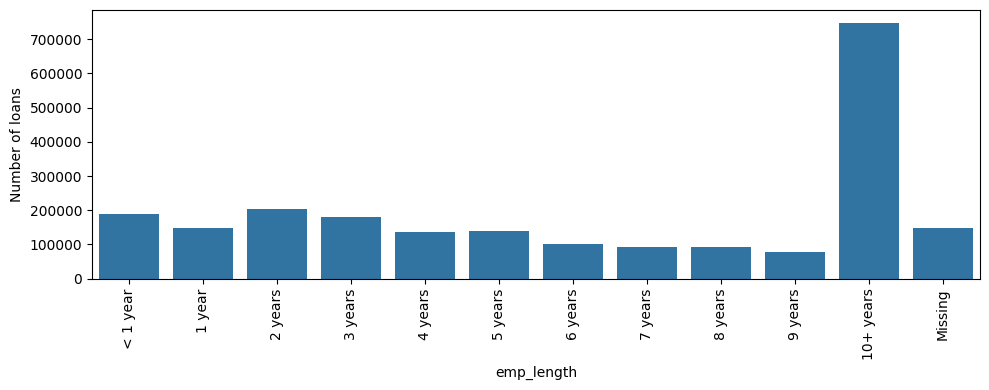

In [16]:
emp_length_order = ["< 1 year", "1 year"] + [f"{i} years" for i in range(2, 10)] + ["10+ years", "Missing"]

emp_length_counts = df["emp_length"].fillna("Missing").value_counts()
emp_length_order = (
    [v for v in emp_length_order if v in emp_length_counts.index]
    + [v for v in emp_length_counts.index if v not in emp_length_order]
)

plt.figure(figsize=(10, 4))
sns.barplot(x=emp_length_counts.reindex(emp_length_order).index,
            y=emp_length_counts.reindex(emp_length_order).values)
plt.xlabel("emp_length")
plt.ylabel("Number of loans")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- `emp_length` has 6.5% missing values. This is too large a share to drop without further investigation.
- The missing values will be kept as a separate category for now. Missingness may itself be informative (for example, when employment length is not reported), so its relationship with `loan_status` will be examined in the EDA before the final treatment is decided.

## 5. Domain Notes

- **Credit inquiries (`inq_last_6mths`, `inq_last_12m`):** lenders commonly treat more than three to four hard inquiries within six months as a warning sign, because it may indicate that the borrower is seeking several lines of credit at once.
- **FICO score:** a three-digit credit score between 300 and 850 that estimates how likely a borrower is to repay a loan. FICO reports that its scores are used by about 90% of top US lenders. In this dataset the score is given as a range (`fico_range_low`, `fico_range_high`) recorded at origination.
- **`delinq_2yrs`:** the number of 30+ days past-due delinquency incidences in the borrower's credit file during the previous two years.

## 6. Column Significance at the Prediction Point

**Principle:** the model may use only information that is legitimately available at the application-time prediction point. Information generated after the application is evaluated or the loan is issued must not be used as an input feature.

Each column is assigned to a category below, and each category receives a decision.

In [17]:
column_categories = {
    "Application Information": [
        "loan_amnt",
        "term",
        "emp_length",
        "home_ownership",
        "annual_inc",
        "verification_status",
        "purpose",
        "zip_code",
        "addr_state",
        "dti",
        "application_type",
    ],

    "Credit History": [
        "delinq_2yrs",
        "earliest_cr_line",
        "fico_range_low",
        "fico_range_high",
        "inq_last_6mths",
        "mths_since_last_delinq",
        "mths_since_last_record",
        "open_acc",
        "pub_rec",
        "revol_bal",
        "revol_util",
        "total_acc",
        "collections_12_mths_ex_med",
        "mths_since_last_major_derog",
        "acc_now_delinq",
        "tot_coll_amt",
        "tot_cur_bal",
        "open_acc_6m",
        "open_act_il",
        "open_il_12m",
        "open_il_24m",
        "mths_since_rcnt_il",
        "total_bal_il",
        "il_util",
        "open_rv_12m",
        "open_rv_24m",
        "max_bal_bc",
        "all_util",
        "total_rev_hi_lim",
        "inq_fi",
        "total_cu_tl",
        "inq_last_12m",
        "acc_open_past_24mths",
        "avg_cur_bal",
        "bc_open_to_buy",
        "bc_util",
        "chargeoff_within_12_mths",
        "delinq_amnt",
        "mo_sin_old_il_acct",
        "mo_sin_old_rev_tl_op",
        "mo_sin_rcnt_rev_tl_op",
        "mo_sin_rcnt_tl",
        "mort_acc",
        "mths_since_recent_bc",
        "mths_since_recent_bc_dlq",
        "mths_since_recent_inq",
        "mths_since_recent_revol_delinq",
        "num_accts_ever_120_pd",
        "num_actv_bc_tl",
        "num_actv_rev_tl",
        "num_bc_sats",
        "num_bc_tl",
        "num_il_tl",
        "num_op_rev_tl",
        "num_rev_accts",
        "num_rev_tl_bal_gt_0",
        "num_sats",
        "num_tl_120dpd_2m",
        "num_tl_30dpd",
        "num_tl_90g_dpd_24m",
        "num_tl_op_past_12m",
        "pct_tl_nvr_dlq",
        "percent_bc_gt_75",
        "pub_rec_bankruptcies",
        "tax_liens",
        "tot_hi_cred_lim",
        "total_bal_ex_mort",
        "total_bc_limit",
        "total_il_high_credit_limit",
    ],

    "Joint Application / Credit History": [
        "annual_inc_joint",
        "dti_joint",
        "verification_status_joint",
        "revol_bal_joint",
        "sec_app_fico_range_low",
        "sec_app_fico_range_high",
        "sec_app_earliest_cr_line",
        "sec_app_inq_last_6mths",
        "sec_app_mort_acc",
        "sec_app_open_acc",
        "sec_app_revol_util",
        "sec_app_open_act_il",
        "sec_app_num_rev_accts",
        "sec_app_chargeoff_within_12_mths",
        "sec_app_collections_12_mths_ex_med",
        "sec_app_mths_since_last_major_derog",
    ],

    "Lender-Assigned / Listing Attributes": [
        "int_rate",
        "installment",
        "grade",
        "sub_grade",
        "initial_list_status",
    ],

    "Funding / Loan Issuance": [
        "funded_amnt",
        "funded_amnt_inv",
        "issue_d",
        "disbursement_method",
    ],

    "Post-Loan Performance": [
        "out_prncp",
        "out_prncp_inv",
        "total_pymnt",
        "total_pymnt_inv",
        "total_rec_prncp",
        "total_rec_int",
        "total_rec_late_fee",
        "recoveries",
        "collection_recovery_fee",
        "last_pymnt_d",
        "last_pymnt_amnt",
        "next_pymnt_d",
        "last_credit_pull_d",
        "last_fico_range_high",
        "last_fico_range_low",
        "pymnt_plan",
    ],

    "Hardship / Payment Modification": [
        "hardship_flag",
        "hardship_type",
        "hardship_reason",
        "hardship_status",
        "deferral_term",
        "hardship_amount",
        "hardship_start_date",
        "hardship_end_date",
        "payment_plan_start_date",
        "hardship_length",
        "hardship_dpd",
        "hardship_loan_status",
        "orig_projected_additional_accrued_interest",
        "hardship_payoff_balance_amount",
        "hardship_last_payment_amount",
    ],

    "Debt Settlement": [
        "debt_settlement_flag",
        "debt_settlement_flag_date",
        "settlement_status",
        "settlement_date",
        "settlement_amount",
        "settlement_percentage",
        "settlement_term",
    ],

    "Identifiers / Administrative": [
        "id",
        "member_id",
        "url",
        "policy_code",
    ],

    "Text / Free Text": [
        "emp_title",
        "title",
        "desc",
    ],

    "Target": [
        "loan_status",
    ],

}

In [18]:
column_meanings = {
    "id": "Unique identifier assigned to the loan",
    "member_id": "Unique identifier of the borrower/member",
    "loan_amnt": "Amount of money requested by the borrower",
    "funded_amnt": "Amount of the requested loan actually funded",
    "funded_amnt_inv": "Amount of the funded loan contributed by investors",
    "term": "Loan repayment duration in months",
    "int_rate": "Interest rate charged on the loan",
    "installment": "Monthly payment amount scheduled for the loan",
    "grade": "Loan risk grade assigned by the lender",
    "sub_grade": "Detailed risk grade assigned to the loan",
    "emp_title": "Job title or occupation of the borrower",
    "emp_length": "Length of the borrower's employment in years (from under 1 year to 10 or more years)",
    "home_ownership": "Borrower's home ownership status",
    "annual_inc": "Borrower's self-reported annual income",
    "verification_status": "Whether the borrower's income (or its source) was verified by the lender",
    "issue_d": "Date on which the loan was issued",
    "loan_status": "Current or final status/outcome of the loan",
    "pymnt_plan": "Indicates whether a payment plan has been put in place for the loan",
    "url": "URL associated with the loan listing",
    "desc": "Borrower's description or explanation of the loan",
    "purpose": "Purpose for which the borrower requested the loan",
    "title": "Title provided by the borrower for the loan",
    "zip_code": "ZIP code of the borrower's address",
    "addr_state": "State of the borrower's address",
    "dti": "Ratio of the borrower's monthly debt payments (excluding mortgage and the requested loan) to self-reported monthly income",
    "delinq_2yrs": "Number of 30+ days past-due delinquency incidences in the borrower's credit file during the previous two years",
    "earliest_cr_line": "Date when the borrower's oldest credit account was opened",
    "fico_range_low": "Lower bound of the borrower's FICO score range at loan origination",
    "fico_range_high": "Upper bound of the borrower's FICO score range at loan origination",
    "inq_last_6mths": "Number of credit inquiries during the previous six months (excluding auto and mortgage inquiries)",
    "mths_since_last_delinq": "Months since the borrower's most recent delinquency",
    "mths_since_last_record": "Months since the borrower's most recent public record",
    "open_acc": "Number of currently open credit accounts",
    "pub_rec": "Number of derogatory public records",
    "revol_bal": "Total outstanding revolving credit balance",
    "revol_util": "Percentage of revolving credit currently being used",
    "total_acc": "Total number of credit accounts",
    "initial_list_status": "Initial listing status of the loan (values W and F)",
    "out_prncp": "Outstanding principal remaining on the loan",
    "out_prncp_inv": "Outstanding principal remaining for investors",
    "total_pymnt": "Total amount of payments received on the loan",
    "total_pymnt_inv": "Total amount of payments received by investors",
    "total_rec_prncp": "Total principal amount received from the borrower",
    "total_rec_int": "Total interest amount received from the borrower",
    "total_rec_late_fee": "Total late-payment fees received",
    "recoveries": "Amount recovered after the loan was charged off",
    "collection_recovery_fee": "Fee collected from recovery/collection activity",
    "last_pymnt_d": "Date of the most recent payment",
    "last_pymnt_amnt": "Amount of the most recent payment",
    "next_pymnt_d": "Scheduled date of the next payment",
    "last_credit_pull_d": "Date when the borrower's credit information was last pulled",
    "last_fico_range_high": "Upper bound of the most recently recorded FICO range",
    "last_fico_range_low": "Lower bound of the most recently recorded FICO range",
    "collections_12_mths_ex_med": "Number of collections during the previous 12 months excluding medical collections",
    "mths_since_last_major_derog": "Months since the most recent 90-day or worse rating",
    "policy_code": "Lending policy code associated with the loan",
    "application_type": "Whether the application is individual or joint",
    "annual_inc_joint": "Combined annual income reported for a joint application",
    "dti_joint": "Combined debt-to-income ratio for a joint application",
    "verification_status_joint": "Income verification status for a joint application",
    "acc_now_delinq": "Number of accounts currently delinquent",
    "tot_coll_amt": "Total collection amounts ever owed",
    "tot_cur_bal": "Total current balance across credit accounts",
    "open_acc_6m": "Number of credit accounts opened in the recent six-month period",
    "open_act_il": "Number of currently active installment accounts",
    "open_il_12m": "Number of installment accounts opened in the previous 12 months",
    "open_il_24m": "Number of installment accounts opened in the previous 24 months",
    "mths_since_rcnt_il": "Months since the most recently opened installment account",
    "total_bal_il": "Total balance of installment accounts",
    "il_util": "Ratio of total current balance to credit limit across all installment accounts",
    "open_rv_12m": "Number of revolving accounts opened in the previous 12 months",
    "open_rv_24m": "Number of revolving accounts opened in the previous 24 months",
    "max_bal_bc": "Maximum current balance owed across all revolving accounts",
    "all_util": "Overall utilization across credit accounts",
    "total_rev_hi_lim": "Total revolving credit limit",
    "inq_fi": "Number of personal finance inquiries",
    "total_cu_tl": "Total number of finance/trade accounts",
    "inq_last_12m": "Number of credit inquiries during the previous 12 months",
    "acc_open_past_24mths": "Number of accounts opened during the previous 24 months",
    "avg_cur_bal": "Average current balance across credit accounts",
    "bc_open_to_buy": "Available credit on bankcard accounts",
    "bc_util": "Bankcard credit utilization",
    "chargeoff_within_12_mths": "Number of charge-offs during the previous 12 months",
    "delinq_amnt": "Past-due amount owed on accounts on which the borrower is currently delinquent",
    "mo_sin_old_il_acct": "Months since the oldest installment account was opened",
    "mo_sin_old_rev_tl_op": "Months since the oldest revolving account was opened",
    "mo_sin_rcnt_rev_tl_op": "Months since the most recently opened revolving account",
    "mo_sin_rcnt_tl": "Months since the most recently opened credit account",
    "mort_acc": "Number of mortgage accounts",
    "mths_since_recent_bc": "Months since the most recently opened bankcard account",
    "mths_since_recent_bc_dlq": "Months since the most recent bankcard delinquency",
    "mths_since_recent_inq": "Months since the most recent credit inquiry",
    "mths_since_recent_revol_delinq": "Months since the most recent revolving-account delinquency",
    "num_accts_ever_120_pd": "Number of accounts that have ever been 120 or more days past due",
    "num_actv_bc_tl": "Number of currently active bankcard accounts",
    "num_actv_rev_tl": "Number of currently active revolving accounts",
    "num_bc_sats": "Number of satisfactory bankcard accounts",
    "num_bc_tl": "Total number of bankcard accounts",
    "num_il_tl": "Total number of installment accounts",
    "num_op_rev_tl": "Number of currently open revolving accounts",
    "num_rev_accts": "Total number of revolving accounts",
    "num_rev_tl_bal_gt_0": "Number of revolving accounts with a balance greater than zero",
    "num_sats": "Number of satisfactory credit accounts",
    "num_tl_120dpd_2m": "Number of accounts currently 120 or more days past due (updated within the past two months)",
    "num_tl_30dpd": "Number of accounts currently 30 days past due (updated within the past two months)",
    "num_tl_90g_dpd_24m": "Number of accounts 90 or more days past due during the previous 24 months",
    "num_tl_op_past_12m": "Number of accounts opened during the previous 12 months",
    "pct_tl_nvr_dlq": "Percentage of credit accounts that have never been delinquent",
    "percent_bc_gt_75": "Percentage of bankcards using more than 75 percent of their limit",
    "pub_rec_bankruptcies": "Number of public-record bankruptcies",
    "tax_liens": "Number of tax liens",
    "tot_hi_cred_lim": "Total high credit limit across credit accounts",
    "total_bal_ex_mort": "Total credit balance excluding mortgage accounts",
    "total_bc_limit": "Total credit limit across bankcard accounts",
    "total_il_high_credit_limit": "Total high credit limit across installment accounts",
    "revol_bal_joint": "Combined revolving credit balance for joint applicants",
    "sec_app_fico_range_low": "Lower bound of the secondary applicant's FICO score range",
    "sec_app_fico_range_high": "Upper bound of the secondary applicant's FICO score range",
    "sec_app_earliest_cr_line": "Date when the secondary applicant's oldest credit account was opened",
    "sec_app_inq_last_6mths": "Secondary applicant's credit inquiries during the previous six months",
    "sec_app_mort_acc": "Number of mortgage accounts held by the secondary applicant",
    "sec_app_open_acc": "Number of open credit accounts held by the secondary applicant",
    "sec_app_revol_util": "Revolving credit utilization of the secondary applicant",
    "sec_app_open_act_il": "Number of active installment accounts held by the secondary applicant",
    "sec_app_num_rev_accts": "Number of revolving accounts held by the secondary applicant",
    "sec_app_chargeoff_within_12_mths": "Secondary applicant's charge-offs during the previous 12 months",
    "sec_app_collections_12_mths_ex_med": "Secondary applicant's collections during the previous 12 months excluding medical collections",
    "sec_app_mths_since_last_major_derog": "Months since the secondary applicant's most recent major derogatory event",
    "hardship_flag": "Indicates whether the borrower entered a hardship program",
    "hardship_type": "Type of hardship assistance provided",
    "hardship_reason": "Reason for the hardship program",
    "hardship_status": "Current status of the hardship program",
    "deferral_term": "Number of months for which payments were deferred",
    "hardship_amount": "Monthly interest payment the borrower committed to make during the hardship plan",
    "hardship_start_date": "Date the hardship plan started",
    "hardship_end_date": "Date the hardship plan ended",
    "payment_plan_start_date": "Date the hardship payment plan started",
    "hardship_length": "Duration of the hardship program",
    "hardship_dpd": "Account days past due as of the start date of the hardship plan",
    "hardship_loan_status": "Loan status while under the hardship program",
    "orig_projected_additional_accrued_interest": "Projected additional interest resulting from the hardship plan",
    "hardship_payoff_balance_amount": "Payoff balance associated with the hardship plan",
    "hardship_last_payment_amount": "Last payment amount as of the start date of the hardship plan",
    "disbursement_method": "Method used to disburse the loan funds",
    "debt_settlement_flag": "Indicates whether a charged-off borrower is working with a debt-settlement company",
    "debt_settlement_flag_date": "Date the debt settlement flag was recorded",
    "settlement_status": "Status of the debt settlement process",
    "settlement_date": "Date the debt settlement occurred",
    "settlement_amount": "Amount agreed upon in the debt settlement",
    "settlement_percentage": "Settlement amount as a percentage of the payoff balance of the loan",
    "settlement_term": "Duration of the debt settlement arrangement",
}

In [19]:
column_reference_df = pd.DataFrame(
    [
        {
            "Column": col,
            "What it represents": column_meanings[col],
            "Type / stage": category,
        }
        for category, columns in column_categories.items()
        for col in columns
    ]
)

with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(column_reference_df)

,Column,What it represents,Type / stage
0,loan_amnt,Amount of money requested by the borrower,Application Information
1,term,Loan repayment duration in months,Application Information
2,emp_length,Length of the borrower's employment in years (from under 1 year to 10 or more years),Application Information
3,home_ownership,Borrower's home ownership status,Application Information
4,annual_inc,Borrower's self-reported annual income,Application Information
5,verification_status,Whether the borrower's income (or its source) was verified by the lender,Application Information
6,purpose,Purpose for which the borrower requested the loan,Application Information
7,zip_code,ZIP code of the borrower's address,Application Information
8,addr_state,State of the borrower's address,Application Information
9,dti,Ratio of the borrower's monthly debt payments (excluding mortgage and the requested loan) to self-reported monthly income,Application Information


| Category | Understanding | Initial decision |
| --- | --- | --- |
| **Application Information** | Information provided by the borrower during the loan application | **Include as candidate features** |
| **Credit History** | Credit-bureau information available when the borrower is evaluated | **Include as candidate features** |
| **Joint Application / Credit History** | Additional applicant and credit information available only for joint applications | **Include as candidate features when applicable** |
| **Lender-Assigned / Listing Attributes** | Terms and attributes produced by the lender's own risk assessment and listing process (`grade`, `sub_grade`, `int_rate`, `installment`, `initial_list_status`) | **Exclude from application-time model** |
| **Funding / Loan Issuance** | Information generated when the loan is funded or issued | **Exclude from application-time model** |
| **Post-Loan Performance** | Information generated by repayment behaviour after issuance | **Exclude from application-time model** |
| **Hardship / Payment Modification** | Information generated when a borrower enters a hardship or payment-modification plan after origination | **Exclude from application-time model** |
| **Debt Settlement** | Information generated by later debt-settlement activity | **Exclude from application-time model** |
| **Identifiers / Administrative** | IDs, URLs and administrative fields used mainly for identification and management | **Investigate, likely exclude** |
| **Text / Free Text** | Free-text fields: employment title, loan title and borrower description | **Investigate separately** |
| **Target (`loan_status`)** | Current or final loan outcome, used to define the prediction target | **Target, not a feature** |

**Lender-assigned attributes:** `grade`, `sub_grade` and `int_rate` are the output of the lender's own risk assessment, and `installment` is calculated from `int_rate`. They are not known before the application is evaluated, and using them would largely reproduce the lender's existing credit decision. They are excluded from the application-time model. If the prediction point is redefined as "after the loan offer", they can be reconsidered.

## 7. Identifiers / Administrative Columns

In [20]:
identifier_cols = column_categories["Identifiers / Administrative"]

identifier_info = pd.DataFrame({
    "Column": identifier_cols,
    "Data_Type": df[identifier_cols].dtypes.astype(str).values,
    "Null_%": df[identifier_cols].isna().mean().mul(100).values,
    "Unique_Values": df[identifier_cols].nunique(dropna=True).values,
    "Unique_%": (df[identifier_cols].nunique(dropna=True) / len(df) * 100).values,
})

identifier_info

,Column,Data_Type,Null_%,Unique_Values,Unique_%
0,id,object,0.00000,2260701,100.000000
1,member_id,Int64,100.00000,0,0.000000
2,url,object,0.00146,2260668,99.998540
3,policy_code,float64,0.00146,1,0.000044


`id`, `member_id`, `url` and `policy_code` were checked for missingness, uniqueness and variability. They carry no borrower-level predictive information for the application-time model and are **excluded**.

## 8. Text / Free-Text Columns

In [21]:
text_cols = column_categories["Text / Free Text"]

text_info = pd.DataFrame({
    "Column": text_cols,
    "Data_Type": df[text_cols].dtypes.astype(str).values,
    "Null_%": df[text_cols].isna().mean().mul(100).values,
    "Unique_Values": df[text_cols].nunique(dropna=True).values,
    "Unique_%": (df[text_cols].nunique(dropna=True) / len(df) * 100).values,
})

text_info

,Column,Data_Type,Null_%,Unique_Values,Unique_%
0,emp_title,object,7.387178,512694,22.678541
1,title,object,1.033264,63154,2.793558
2,desc,object,94.423632,124500,5.507141


In [22]:
for col in text_cols:
    print(f"\n{'=' * 50}")
    print(f"Column: {col}")
    print(f"{'=' * 50}")

    print("Sample values:")
    print(df[col].dropna().sample(min(5, df[col].notna().sum()), random_state=42).tolist())

    print("Average text length:", df[col].dropna().astype(str).str.len().mean())


Column: emp_title
Sample values:
['VP, Product Innovation', 'aircraft inspector', 'Robert L Ott Insurance', 'Computer Specialist', 'Senior Field Engineer']
Average text length: 15.596127714633289

Column: title
Sample values:
['Debt consolidation', 'Home improvement', 'Credit card refinancing', 'Debt Consolidation Loan', 'Home improvement']
Average text length: 17.69166314314039

Column: desc
Sample values:
["I've ended up with a few loans from different places, and with relatively poor interest rates in retrospect. I would like to have one convenient payment per month, and hopefully a better interest rate.  I am paying off a small personal loan, a bit of credit card balance, and a loan used to buy a Marimba One 5 octave marimba for my wife (a recent music graduate).   I have very good credit and steady income, I would just like to consolidate a few things.  Thanks for your consideration!", '  Borrower added on 10/29/13 > We have incurred a credit card loan over the past 10 yrs to Cap

`desc` has very high missingness (about 94.42%) and is excluded. `emp_title` and `title` are investigated further below before a decision is made.

In [23]:
def investigate_text_columns(
    df,
    text_cols,
    target_col="loan_status",
    related_cols=None,
    top_n=20
):
    """
    Comprehensive investigation of text/free-text columns.

    Investigates:
    - Data type
    - Missingness
    - Empty strings
    - Raw cardinality
    - Normalized cardinality
    - Average / median / min / max text length
    - Rare-value concentration
    - Top-value coverage
    - Target availability
    - Relationship with target for common values
    - Relationship with related categorical columns

    Returns:
        summary_df
        analysis_results
    """

    if related_cols is None:
        related_cols = []

    summary = []
    analysis_results = {}

    for col in text_cols:

        s = df[col]

        # Basic investigation
        non_null = s.dropna().astype("string").str.strip()

        missing_count = s.isna().sum()
        missing_pct = s.isna().mean() * 100

        empty_count = non_null.eq("").sum()

        raw_unique = s.nunique(dropna=True)

        # Normalize text
        normalized = (
            non_null
            .str.lower()
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

        normalized_unique = normalized.nunique()

        # Text length
        lengths = normalized.str.len()

        # Frequency analysis
        value_counts = normalized.value_counts()

        unique_once = (value_counts == 1).sum()
        unique_once_pct = (
            unique_once / len(value_counts) * 100
            if len(value_counts) > 0 else 0
        )

        top_n_coverage = (
            value_counts.head(top_n).sum()
            / value_counts.sum()
            * 100
            if value_counts.sum() > 0 else 0
        )

        # Target relationship
        target_table = None

        if target_col in df.columns:

            valid_mask = normalized.notna() & df[target_col].notna()

            temp = pd.DataFrame({
                "text": normalized[valid_mask],
                "target": df.loc[valid_mask, target_col]
            })

            top_values = (
                temp["text"]
                .value_counts()
                .head(top_n)
                .index
            )

            target_table = pd.crosstab(
                temp.loc[temp["text"].isin(top_values), "text"],
                temp.loc[temp["text"].isin(top_values), "target"],
                normalize="index"
            ).round(4)

        # Related-column analysis
        related_analysis = {}

        for related_col in related_cols:

            if related_col not in df.columns:
                continue

            mask = normalized.notna() & df[related_col].notna()

            temp = pd.DataFrame({
                "text": normalized[mask],
                "related": df.loc[mask, related_col]
            })

            top_values = (
                temp["text"]
                .value_counts()
                .head(top_n)
                .index
            )

            related_analysis[related_col] = pd.crosstab(
                temp.loc[temp["text"].isin(top_values), "text"],
                temp.loc[temp["text"].isin(top_values), "related"],
                normalize="index"
            ).round(4)

        # Store summary
        summary.append({
            "Column": col,
            "Data_Type": str(s.dtype),

            "Rows": len(df),

            "Missing_Count": missing_count,
            "Missing_%": missing_pct,

            "Empty_String_Count": empty_count,
            "Empty_String_%": empty_count / len(df) * 100,

            "Raw_Unique": raw_unique,
            "Raw_Unique_%": raw_unique / len(df) * 100,

            "Normalized_Unique": normalized_unique,
            "Normalized_Unique_%": normalized_unique / len(df) * 100,

            "Avg_Text_Length": lengths.mean(),
            "Median_Text_Length": lengths.median(),
            "Min_Text_Length": lengths.min(),
            "Max_Text_Length": lengths.max(),

            "Unique_Values_Occurring_Once": unique_once,
            "Unique_Values_Occurring_Once_%": unique_once_pct,

            f"Top_{top_n}_Coverage_%": top_n_coverage
        })

        analysis_results[col] = {
            "top_values": value_counts.head(top_n),
            "target_distribution": target_table,
            "related_columns": related_analysis
        }

    # Final summary DataFrame
    summary_df = pd.DataFrame(summary)

    summary_df = summary_df.round(2)

    # Print final investigation
    print("\n" + "=" * 80)
    print("TEXT COLUMN INVESTIGATION SUMMARY")
    print("=" * 80)

    display(summary_df)

    for col in text_cols:

        print("\n" + "=" * 80)
        print(f"DETAILED INVESTIGATION: {col}")
        print("=" * 80)

        print("\nTop Values:")
        display(analysis_results[col]["top_values"])

        if analysis_results[col]["target_distribution"] is not None:
            print("\nTarget Distribution of Top Values:")
            display(
                analysis_results[col]["target_distribution"]
            )

        for related_col, table in (
            analysis_results[col]["related_columns"].items()
        ):
            print(f"\nRelationship with {related_col}:")
            display(table)

    return summary_df, analysis_results

In [24]:
text_summary, text_analysis = investigate_text_columns(
    df=df,
    text_cols=["emp_title", "title"],
    target_col="loan_status",
    related_cols=["emp_length", "purpose"],
    top_n=20,
)


TEXT COLUMN INVESTIGATION SUMMARY


,Column,Data_Type,Rows,Missing_Count,Missing_%,Empty_String_Count,Empty_String_%,Raw_Unique,Raw_Unique_%,Normalized_Unique,Normalized_Unique_%,Avg_Text_Length,Median_Text_Length,Min_Text_Length,Max_Text_Length,Unique_Values_Occurring_Once,Unique_Values_Occurring_Once_%,Top_20_Coverage_%
0,emp_title,object,2260701,167002,7.39,3,0.0,512694,22.68,410139,18.14,15.50,15.0,0,78,304780,74.31,16.97
1,title,object,2260701,23359,1.03,0,0.0,63154,2.79,51646,2.28,17.69,18.0,2,80,43569,84.36,93.84



DETAILED INVESTIGATION: emp_title

Top Values:


emp_title
teacher               48460
manager               45852
owner                 33591
registered nurse      23422
supervisor            22306
driver                22267
sales                 18984
rn                    17196
office manager        14247
project manager       13859
general manager       13349
truck driver          12842
director              10595
president              9826
engineer               8978
sales manager          8542
operations manager     8194
police officer         7685
vice president         7627
technician             7437
Name: count, dtype: Int64


Target Distribution of Top Values:


...

target,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
text,,,,,,,,,
business,0.1748,0.4078,0.0000,0.0001,0.0001,0.3924,0.0053,0.0033,0.0162
car financing,0.0861,0.4383,0.0001,0.0000,0.0001,0.4611,0.0036,0.0014,0.0093
consolidate,0.1589,0.0000,0.0000,0.0050,0.0059,0.8301,0.0000,0.0000,0.0000
consolidation,0.1514,0.0000,0.0000,0.0015,0.0039,0.8430,0.0001,0.0000,0.0000
consolidation loan,0.1413,0.0000,0.0000,0.0007,0.0033,0.8547,0.0000,0.0000,0.0000
credit card consolidation,0.1101,0.0000,0.0000,0.0005,0.0049,0.8845,0.0000,0.0000,0.0000
credit card payoff,0.1186,0.0000,0.0000,0.0008,0.0043,0.8760,0.0000,0.0000,0.0004
credit card refinance,0.1195,0.0000,0.0000,0.0004,0.0016,0.8781,0.0000,0.0000,0.0004
credit card refinancing,0.0931,0.4539,0.0000,0.0000,0.0000,0.4394,0.0035,0.0017,0.0084



Relationship with emp_length:


related,1 year,10+ years,2 years,3 years,4 years,5 years,6 years,7 years,8 years,9 years,< 1 year
text,,,,,,,,,,,
business,0.0742,0.3004,0.1087,0.0992,0.0708,0.0704,0.0479,0.0468,0.0437,0.0341,0.1037
car financing,0.0801,0.3166,0.1071,0.0925,0.0686,0.0710,0.0476,0.0403,0.0388,0.0329,0.1045
consolidate,0.0591,0.3929,0.0766,0.0728,0.0572,0.0757,0.0648,0.0643,0.0426,0.0383,0.0558
consolidation,0.0697,0.3553,0.0885,0.0762,0.0567,0.0743,0.0596,0.0598,0.0549,0.0368,0.0682
consolidation loan,0.0669,0.3380,0.0951,0.0776,0.0620,0.0745,0.0646,0.0498,0.0544,0.0407,0.0764
credit card consolidation,0.0763,0.2724,0.1094,0.0884,0.0640,0.0799,0.0626,0.0555,0.0432,0.0418,0.1066
credit card payoff,0.0594,0.3170,0.0873,0.0776,0.0708,0.0764,0.0679,0.0687,0.0461,0.0380,0.0906
credit card refinance,0.0755,0.2774,0.1068,0.0861,0.0581,0.0881,0.0699,0.0621,0.0447,0.0410,0.0902
credit card refinancing,0.0756,0.3329,0.1023,0.0901,0.0660,0.0652,0.0467,0.0422,0.0425,0.0363,0.1004



Relationship with purpose:


related,car,credit_card,debt_consolidation,educational,home_improvement,house,major_purchase,medical,moving,other,renewable_energy,small_business,vacation,wedding
text,,,,,,,,,,,,,,
business,0.0001,0.0004,0.0014,0.0000,0.0002,0.0001,0.0004,0.0000,0.0000,0.0016,0.0000,0.9956,0.0000,0.0000
car financing,0.9978,0.0002,0.0010,0.0000,0.0003,0.0000,0.0002,0.0000,0.0000,0.0004,0.0000,0.0001,0.0000,0.0000
consolidate,0.0018,0.1370,0.8260,0.0000,0.0046,0.0000,0.0059,0.0005,0.0005,0.0219,0.0009,0.0009,0.0000,0.0000
consolidation,0.0002,0.1276,0.8492,0.0000,0.0036,0.0002,0.0023,0.0004,0.0002,0.0147,0.0000,0.0007,0.0006,0.0001
consolidation loan,0.0011,0.1242,0.8595,0.0004,0.0022,0.0000,0.0026,0.0004,0.0000,0.0085,0.0000,0.0004,0.0004,0.0004
credit card consolidation,0.0005,0.4801,0.5098,0.0000,0.0019,0.0003,0.0011,0.0005,0.0000,0.0054,0.0000,0.0003,0.0000,0.0000
credit card payoff,0.0004,0.6349,0.3558,0.0000,0.0016,0.0000,0.0000,0.0000,0.0000,0.0070,0.0000,0.0000,0.0004,0.0000
credit card refinance,0.0016,0.9737,0.0220,0.0000,0.0004,0.0004,0.0004,0.0000,0.0000,0.0016,0.0000,0.0000,0.0000,0.0000
credit card refinancing,0.0000,0.9989,0.0009,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0000,0.0000


- **`title`:** low missingness but high raw cardinality. Most values are highly repetitive and closely aligned with `purpose`, so the column adds largely redundant information. It is excluded from the current feature set. Text-based feature extraction may be considered in a later experiment.
- **`emp_title`:** the loan-status distribution differs among frequently occurring titles, so the column may carry predictive information. However, its very high cardinality and large share of rare values make direct categorical encoding impractical. Using it would require text normalisation, occupation grouping or NLP-based feature engineering. It is excluded from the baseline feature set and may be evaluated in a later feature-engineering experiment.

| Column | Final decision | Reason |
| --- | --- | --- |
| `emp_title` | **Exclude from current model** | 7.39% missing, about 410K normalised unique values, and 74.31% of unique values occur only once. It may contain useful information, but direct categorical encoding is impractical and dedicated NLP or occupation grouping would be required. |
| `desc` | **Exclude** | 94.42% missing and highly unstructured free text. |
| `title` | **Exclude** | Low missingness, but largely redundant with `purpose`; the most common titles map almost directly to purpose categories. |

**Decision:** `emp_title`, `desc` and `title` are excluded from the current feature set.

## 9. Final Column Classification

Decisions are applied to the categories defined in Section 6, so that every column has a single, consistent classification.

In [25]:
category_decisions = {
    "Application Information": "Include as candidate feature",
    "Credit History": "Include as candidate feature",
    "Joint Application / Credit History": "Include as candidate feature (joint applications only)",
    "Lender-Assigned / Listing Attributes": "Exclude from feature set",
    "Funding / Loan Issuance": "Exclude from feature set",
    "Post-Loan Performance": "Exclude from feature set",
    "Hardship / Payment Modification": "Exclude from feature set",
    "Debt Settlement": "Exclude from feature set",
    "Identifiers / Administrative": "Exclude from feature set",
    "Text / Free Text": "Exclude from feature set",
    "Target": "Target (not a feature)",
}

classification_df = pd.DataFrame(
    [
        {"Column": col, "Category": category, "Decision": category_decisions[category]}
        for category, columns in column_categories.items()
        for col in columns
    ]
)

include_df = classification_df[classification_df["Decision"].str.startswith("Include")].reset_index(drop=True)
exclude_df = classification_df[~classification_df["Decision"].str.startswith("Include")].reset_index(drop=True)

In [26]:
display(include_df)
display(exclude_df)

,Column,Category,Decision
0,loan_amnt,Application Information,Include as candidate feature
1,term,Application Information,Include as candidate feature
2,emp_length,Application Information,Include as candidate feature
3,home_ownership,Application Information,Include as candidate feature
4,annual_inc,Application Information,Include as candidate feature
...,...,...,...
91,sec_app_open_act_il,Joint Application / Credit History,Include as candidate feature (joint applicatio...
92,sec_app_num_rev_accts,Joint Application / Credit History,Include as candidate feature (joint applicatio...
93,sec_app_chargeoff_within_12_mths,Joint Application / Credit History,Include as candidate feature (joint applicatio...
94,sec_app_collections_12_mths_ex_med,Joint Application / Credit History,Include as candidate feature (joint applicatio...


,Column,Category,Decision
0,int_rate,Lender-Assigned / Listing Attributes,Exclude from feature set
1,installment,Lender-Assigned / Listing Attributes,Exclude from feature set
2,grade,Lender-Assigned / Listing Attributes,Exclude from feature set
3,sub_grade,Lender-Assigned / Listing Attributes,Exclude from feature set
4,initial_list_status,Lender-Assigned / Listing Attributes,Exclude from feature set
5,funded_amnt,Funding / Loan Issuance,Exclude from feature set
6,funded_amnt_inv,Funding / Loan Issuance,Exclude from feature set
7,issue_d,Funding / Loan Issuance,Exclude from feature set
8,disbursement_method,Funding / Loan Issuance,Exclude from feature set
9,out_prncp,Post-Loan Performance,Exclude from feature set


### Classification check

In [27]:
classified = classification_df["Column"]

duplicated_columns = classified[classified.duplicated()].tolist()
missing_columns = set(df.columns) - set(classified)
extra_columns = set(classified) - set(df.columns)

print(f"Original columns   : {df.shape[1]}")
print(f"Included columns   : {len(include_df)}")
print(f"Excluded columns   : {len(exclude_df)}")
print(f"Total classified   : {classified.nunique()}")
print(f"Duplicated entries : {duplicated_columns}")
print(f"Missing from classification   : {missing_columns}")
print(f"Not present in the dataset    : {extra_columns}")

assert not duplicated_columns and not missing_columns and not extra_columns

Original columns   : 151
Included columns   : 96
Excluded columns   : 55
Total classified   : 151
Duplicated entries : []
Missing from classification   : set()
Not present in the dataset    : set()


## 10. Summary and Next Step: Data Cleaning

### Findings
- The dataset has 2,260,701 rows and 151 columns. Of these, 96 columns are candidate features, 54 are excluded because they are identifiers, free text, lender-assigned or generated after the application, and `loan_status` is the target.
- Missingness in the hardship, settlement and joint-application columns is structural ("not applicable"), not random.
- Only 34 rows have missing values in the low-missingness categorical columns. `emp_length` has 6.5% missing values.

### Cleaning plan (notebook 03)
1. **Remove invalid rows.** Inspect the 34 rows with missing categorical values, then drop them. Check for fully duplicated rows.
2. **Define the target.** Convert `loan_status` into a binary default indicator. Remove loans without a known outcome (for example "Current") and record how each status is mapped.
3. **Apply the column selection.** Keep the candidate features, the target and `issue_d` (needed only for time-based splitting, not as a feature).
4. **Fix data types.** Convert `term` to a number, `emp_length` to an ordered numeric value with a separate missing category, the credit-line dates to dates, and `zip_code` to a text field.
5. **Assess missingness in numeric candidates.** Separate structural from random missingness, for example columns introduced only for later loans, and decide between a missing-value indicator, imputation or removal for each group.
6. **Handle joint applications.** Create an application-type indicator and combine the joint and individual income and DTI values.
7. **Check value validity.** Look for impossible or implausible values (for example in `dti`, `annual_inc`, `revol_util`, and FICO low above high) and decide on correction or capping after the EDA.
8. **Clean categorical fields.** Standardise text values and decide how to treat rare categories and high-cardinality fields (`addr_state`, `zip_code`).
9. **Save the result.** Write the cleaned dataset to `data/interim/` as parquet and log the row and column counts after each step.

### Rule for the next stage
Split the data (time-based, using `issue_d`) **before** fitting any imputer, encoder or scaler. These steps must be learned on the training data only, to avoid leakage.